# Bayesian Ordinal Regression with Horseshoe Priors

This analysis extends the basic ordinal regression model to include multiple predictors using **regularized horseshoe priors**. The horseshoe prior is a shrinkage prior that can distinguish between signal and noise in high-dimensional settings, allowing non-zero effects to remain while shrinking small effects toward zero.

## Why Horseshoe Priors?

When we have many predictors, standard regression can overfit the data. Ridge regression (L2) shrinks all coefficients uniformly, while LASSO (L1) can set coefficients exactly to zero but doesn't handle uncertainty well. The horseshoe prior provides:

- **Adaptive shrinkage**: Small effects are shrunk toward zero while large effects remain relatively unaffected
- **Bayesian uncertainty quantification**: Full posterior distributions for all parameters
- **Sparsity-inducing**: Encourages sparse solutions without hard thresholding

## Predictors in This Analysis

**Mental Health Variables:**
- `hlthdep`: Health depression scale (1-5)
- `feeldown`: Feeling down, depressed, or hopeless (over last 2 weeks)
- `nointerest`: Little interest or pleasure in doing things (over last 2 weeks)
- `feelnerv`: Feeling nervous, anxious, or on edge (over last 2 weeks)
- `worry`: Not being able to stop or control worrying (over last 2 weeks)

**Work-Related Variables:**
- `wrkmeangfl`: I find my work to be very meaningful (agreement scale)

**Demographics:**
- `age`: Age in years (centered)
- `sex`: Coded as female indicator

**Note**: Several requested variables (STRESS, FINRELA, DISCAFFMV, WKAGEISM, WKRACISM, WKSEXISM) are not available in the current dataset subset.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
print(f'PyMC version: {pm.__version__}')
print(f'ArviZ version: {az.__version__}')

PyMC version: 5.25.1
ArviZ version: 0.22.0


## Data Loading and Preparation

We load the GSS data and prepare all predictor variables for the model.

In [2]:
# Load the data
data_path = Path('data/gss_subset.csv')
df = pd.read_csv(data_path)

print(f'Full dataset shape: {df.shape}')

# Define predictor variables
predictor_cols = ['hlthdep', 'feeldown', 'nointerest', 'feelnerv', 'worry', 'wrkmeangfl']
demographic_cols = ['age', 'sex']
outcome_col = 'satjob'

# Select relevant columns and drop missing values
analysis_cols = [outcome_col] + predictor_cols + demographic_cols
df_analysis = df[analysis_cols].dropna().copy()

# Filter to valid job satisfaction categories (1-4)
df_analysis = df_analysis[df_analysis['satjob'].isin([1.0, 2.0, 3.0, 4.0])].copy()

print(f'Analysis dataset shape: {df_analysis.shape}')
print(f'Complete cases: {len(df_analysis)}')

Full dataset shape: (75699, 16)
Analysis dataset shape: (554, 9)
Complete cases: 554


In [3]:
# Prepare outcome variable (0-indexed for PyMC)
df_analysis['satjob_coded'] = (df_analysis['satjob'] - 1).astype(int)

# Encode sex as binary (female = 1)
df_analysis['female'] = (df_analysis['sex'] == 2).astype(int)

# Center age on minimum
df_analysis['age_c'] = df_analysis['age'] - df_analysis['age'].min()

# Standardize all predictors for better sampling and interpretation
predictors_to_standardize = predictor_cols + ['age_c']
predictor_means = {}
predictor_stds = {}

for col in predictors_to_standardize:
    predictor_means[col] = df_analysis[col].mean()
    predictor_stds[col] = df_analysis[col].std()
    df_analysis[f'{col}_std'] = (df_analysis[col] - predictor_means[col]) / predictor_stds[col]

# Create final predictor list (standardized versions + female indicator)
final_predictors = [f'{col}_std' for col in predictors_to_standardize] + ['female']

print('Predictor variables:')
for p in final_predictors:
    print(f'  {p}')

# Summary statistics
df_analysis[final_predictors + ['satjob_coded']].describe()

Predictor variables:
  hlthdep_std
  feeldown_std
  nointerest_std
  feelnerv_std
  worry_std
  wrkmeangfl_std
  age_c_std
  female


,hlthdep_std,feeldown_std,nointerest_std,feelnerv_std,worry_std,wrkmeangfl_std,age_c_std,female,satjob_coded
count,5.540000e+02,5.540000e+02,5.540000e+02,5.540000e+02,5.540000e+02,5.540000e+02,5.540000e+02,554.000000,554.000000
mean,7.374767e-17,-9.939903e-17,-6.332680e-17,-6.813643e-17,9.619261e-18,9.138298e-17,9.138298e-17,0.483755,0.696751
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.500188,0.780706
min,-1.045601e+00,-6.012645e-01,-5.732059e-01,-7.628204e-01,-6.798732e-01,-1.168658e+00,-1.789596e+00,0.000000,0.000000
25%,-1.045601e+00,-6.012645e-01,-5.732059e-01,-7.628204e-01,-6.798732e-01,-1.168658e+00,-8.407882e-01,0.000000,0.000000
50%,-1.625782e-01,-6.012645e-01,-5.732059e-01,-7.628204e-01,-6.798732e-01,2.001296e-01,-1.291826e-01,0.000000,1.000000
75%,7.204448e-01,7.101549e-01,8.381543e-01,3.949947e-01,4.971573e-01,2.001296e-01,7.857387e-01,1.000000,1.000000
max,2.486491e+00,3.332994e+00,3.660875e+00,2.710625e+00,2.851218e+00,2.937704e+00,2.480038e+00,1.000000,3.000000


In [4]:
# Visualize predictor distributions
fig = make_subplots(rows=2, cols=4, subplot_titles=[
    'Depression (hlthdep)', 'Feel Down', 'No Interest', 'Feel Nervous',
    'Worry', 'Work Meaningful', 'Age', 'Sex (Female)'
])

raw_predictors = predictor_cols + ['age_c', 'female']
for i, col in enumerate(raw_predictors):
    row = i // 4 + 1
    col_idx = i % 4 + 1
    fig.add_trace(
        go.Histogram(x=df_analysis[col], name=col, showlegend=False),
        row=row, col=col_idx
    )

fig.update_layout(height=500, title='Predictor Distributions')
fig.show()

In [5]:
# Compute correlation matrix for predictors
corr_matrix = df_analysis[predictor_cols + ['age_c', 'female']].corr()

fig = go.Figure(data=go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns,
    y=corr_matrix.columns,
    colorscale='RdBu_r',
    zmin=-1, zmax=1,
    text=np.round(corr_matrix.values, 2),
    texttemplate='%{text}',
    textfont={'size': 10}
))

fig.update_layout(
    title='Predictor Correlation Matrix',
    width=600, height=500
)
fig.show()

print('Note: High correlations among mental health variables suggest potential multicollinearity.')
print('The horseshoe prior helps handle this by shrinking redundant predictors.')

Note: High correlations among mental health variables suggest potential multicollinearity.
The horseshoe prior helps handle this by shrinking redundant predictors.


## The Regularized Horseshoe Prior

The horseshoe prior (Carvalho et al., 2010) is a continuous shrinkage prior that adaptively regularizes regression coefficients. The regularized version (Piironen & Vehtari, 2017) adds a slab component to prevent unbounded coefficients.

### Model Structure

For coefficient $\beta_j$:

$$\beta_j \sim \text{Normal}(0, \tau^2 \tilde{\lambda}_j^2)$$

where:
- $\tau$ is the **global shrinkage** parameter (controls overall sparsity)
- $\lambda_j$ is the **local shrinkage** parameter for predictor $j$
- $\tilde{\lambda}_j$ is the regularized local shrinkage:

$$\tilde{\lambda}_j = \frac{c \lambda_j}{\sqrt{c^2 + \tau^2 \lambda_j^2}}$$

The slab scale $c$ prevents coefficients from becoming arbitrarily large.

### Prior Specifications

- **Global shrinkage** $\tau \sim \text{Half-StudentT}(2, \tau_0)$
  - $\tau_0 = \frac{D_0}{D - D_0} \cdot \frac{1}{\sqrt{N}}$ where $D_0$ is expected number of relevant predictors
- **Local shrinkage** $\lambda_j \sim \text{Half-StudentT}(5, 1)$
- **Slab variance** $c^2 \sim \text{InverseGamma}(1, 1)$

In [6]:
# Prepare data for PyMC model
y_observed = df_analysis['satjob_coded'].values
X = df_analysis[final_predictors].values

N, D = X.shape  # Number of observations and predictors
K = 4  # Number of outcome categories

# Expected number of relevant predictors (prior belief)
# We expect maybe 3-4 predictors to be truly important
D0 = 3

print(f'Number of observations: {N}')
print(f'Number of predictors: {D}')
print(f'Number of outcome categories: {K}')
print(f'Expected relevant predictors (D0): {D0}')
print(f'\nPredictors: {final_predictors}')

Number of observations: 554
Number of predictors: 8
Number of outcome categories: 4
Expected relevant predictors (D0): 3

Predictors: ['hlthdep_std', 'feeldown_std', 'nointerest_std', 'feelnerv_std', 'worry_std', 'wrkmeangfl_std', 'age_c_std', 'female']


In [7]:
# Define the horseshoe ordinal regression model
predictor_names = ['hlthdep', 'feeldown', 'nointerest', 'feelnerv', 'worry', 'wrkmeangfl', 'age', 'female']

with pm.Model(coords={'predictors': predictor_names}) as horseshoe_model:
    
    # Data
    X_data = pm.Data('X_data', X)
    
    # === Regularized Horseshoe Prior ===
    
    # Global shrinkage parameter
    # Scale based on expected sparsity: tau0 = D0 / (D - D0) / sqrt(N)
    tau0 = D0 / (D - D0) * 1 / np.sqrt(N)
    tau = pm.HalfStudentT('tau', nu=2, sigma=tau0)
    
    # Local shrinkage parameters (one per predictor)
    lam = pm.HalfStudentT('lam', nu=5, sigma=1, dims='predictors')
    
    # Slab scale (regularization to prevent unbounded coefficients)
    c2 = pm.InverseGamma('c2', alpha=1, beta=1)
    
    # Regularized local shrinkage
    lam_tilde = lam * pt.sqrt(c2 / (c2 + tau**2 * lam**2))
    
    # Coefficients via non-centered parameterization (better sampling)
    z = pm.Normal('z', mu=0, sigma=1, dims='predictors')
    beta = pm.Deterministic('beta', z * tau * lam_tilde, dims='predictors')
    
    # Intercept (not regularized)
    mu = pm.Normal('mu', mu=0, sigma=2)
    
    # === Ordinal Regression Components ===
    
    # Cutpoints (thresholds) - must be ordered
    cutpoints = pm.Normal('cutpoints', mu=[-1, 0, 1], sigma=2, shape=K-1,
                         transform=pm.distributions.transforms.ordered)
    
    # Linear predictor
    eta = pm.Deterministic('eta', mu + X_data @ beta)
    
    # Likelihood: Ordered logistic
    y_obs = pm.OrderedLogistic('y_obs', 
                              cutpoints=cutpoints,
                              eta=eta, 
                              observed=y_observed)
    
    # Sample from prior
    prior_pred = pm.sample_prior_predictive(samples=500, random_seed=42)

print('Model structure:')
print(f'  Random variables: {[rv.name for rv in horseshoe_model.basic_RVs]}')
print(f'  Free parameters: {[rv.name for rv in horseshoe_model.free_RVs]}')

Sampling: [c2, cutpoints, lam, mu, tau, y_obs, z]


Model structure:
  Random variables: ['tau', 'lam', 'c2', 'z', 'mu', 'cutpoints', 'y_obs']
  Free parameters: ['tau', 'lam', 'c2', 'z', 'mu', 'cutpoints']


ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: random_make_inplace
ERROR (pytensor.graph.rewriting.basic): node: t_rv{"(),(),()->()"}(*0-<RandomGeneratorType>, *1-<NoneTypeT>, *2-<Scalar(int8, shape=())>, 0.0, *3-<Scalar(float64, shape=())>)
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/var/home/fonnesbeck/.local/lib/python3.13/site-packages/pytensor/graph/rewriting/basic.py", line 1922, in process_node
    replacements = node_rewriter.transform(fgraph, node)
  File "/var/home/fonnesbeck/.local/lib/python3.13/site-packages/pytensor/graph/rewriting/basic.py", line 1086, in transform
    return self.fn(fgraph, node)
           ~~~~~~~^^^^^^^^^^^^^^
  File "/var/home/fonnesbeck/.local/lib/python3.13/site-packages/pytensor/tensor/random/rewriting/basic.py", line 50, in random_make_inplace
    new_outputs = new_op.make_node(*node.inputs).outputs
                  ~~~~~~~~~~~~~~~~^^^^^^^

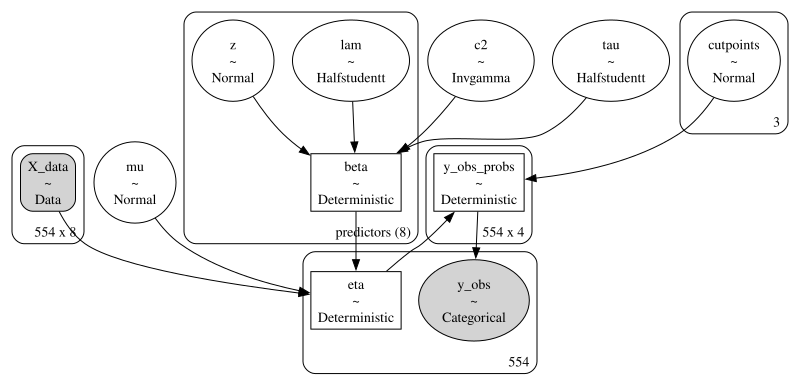

In [8]:
# Visualize the model structure
horseshoe_model.to_graphviz()

## Prior Predictive Checks

Before fitting, let's examine what our horseshoe prior implies about the coefficients and predictions.

In [9]:
# Examine prior distributions
fig = make_subplots(rows=1, cols=2, subplot_titles=['Prior: Coefficients (beta)', 'Prior: Shrinkage (tau * lambda)'])

# Prior coefficient distributions
beta_prior = prior_pred.prior['beta'].values.reshape(-1, D)
for i, name in enumerate(predictor_names):
    fig.add_trace(
        go.Histogram(x=beta_prior[:, i], name=name, opacity=0.6),
        row=1, col=1
    )

# Prior shrinkage distribution
tau_prior = prior_pred.prior['tau'].values.flatten()
lam_prior = prior_pred.prior['lam'].values.reshape(-1, D)
shrinkage = tau_prior[:, None] * lam_prior

for i, name in enumerate(predictor_names):
    fig.add_trace(
        go.Histogram(x=np.clip(shrinkage[:, i], -5, 5), name=name, opacity=0.6, showlegend=False),
        row=1, col=2
    )

fig.update_layout(height=400, barmode='overlay')
fig.update_xaxes(title_text='Coefficient Value', row=1, col=1)
fig.update_xaxes(title_text='Shrinkage Scale (clipped)', row=1, col=2)
fig.show()

print('Prior coefficient summary (should be centered near 0 with heavy tails):')
print(f'  Mean: {beta_prior.mean():.3f}')
print(f'  Std: {beta_prior.std():.3f}')
print(f'  % within [-0.1, 0.1]: {(np.abs(beta_prior) < 0.1).mean() * 100:.1f}%')

Prior coefficient summary (should be centered near 0 with heavy tails):
  Mean: 0.002
  Std: 0.093
  % within [-0.1, 0.1]: 94.7%


## Model Fitting

We fit the model using MCMC sampling with NUTS. The horseshoe prior requires careful tuning due to the heavy-tailed distributions.

In [12]:
# Fit the model
with horseshoe_model:
    # Sample from posterior
    # Higher target_accept for horseshoe priors due to heavy tails
    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.99,
        random_seed=42,
        nuts_sampler='nutpie'
    )
    
    # Posterior predictive
    pm.sample_posterior_predictive(trace, extend_inferencedata=True, random_seed=42)

print('Sampling completed!')

/var/home/fonnesbeck/repos/Koenigsberg_Bayes/.pixi/envs/default/lib/python3.13/site-packages/nutpie/compile_pymc.py:891: NumbaPerformanceWarning:

np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'A', True, aligned=True), Array(float64, 2, 'A', False, aligned=True))



Progress,Draws,Divergences,Step Size,Gradients/Draw
,4000,0,0.06,127
,4000,0,0.06,127
,4000,0,0.07,63
,4000,0,0.07,127


Sampling: [y_obs]


Output()

Sampling completed!


## Convergence Diagnostics

In [13]:
# Check for divergences
if 'diverging' in trace.sample_stats:
    n_divergent = int(trace.sample_stats['diverging'].sum().values)
    print(f'Divergent transitions: {n_divergent}')
    if n_divergent > 0:
        print('  Warning: Consider increasing target_accept or reparameterizing.')
else:
    print('No divergence information available.')

# Summary with convergence diagnostics
summary = az.summary(trace, var_names=['beta', 'tau', 'cutpoints'])
print('\nConvergence diagnostics (R-hat should be < 1.01):')
print(summary[['mean', 'sd', 'hdi_3%', 'hdi_97%', 'r_hat', 'ess_bulk']])

Divergent transitions: 0

Convergence diagnostics (R-hat should be < 1.01):
                   mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
beta[hlthdep]     0.380  0.119   0.169    0.607    1.0    8504.0
beta[feeldown]   -0.046  0.101  -0.259    0.135    1.0    7717.0
beta[nointerest]  0.030  0.086  -0.126    0.207    1.0    9344.0
beta[feelnerv]    0.127  0.114  -0.056    0.345    1.0    5287.0
beta[worry]      -0.036  0.097  -0.231    0.147    1.0    6405.0
beta[wrkmeangfl]  0.880  0.099   0.687    1.059    1.0    8869.0
beta[age]        -0.280  0.094  -0.465   -0.112    1.0    7626.0
beta[female]      0.337  0.188  -0.011    0.668    1.0    4992.0
tau               0.369  0.255   0.083    0.742    1.0    2701.0
cutpoints[0]     -1.759  1.021  -3.643    0.227    1.0    1378.0
cutpoints[1]      0.924  1.019  -0.981    2.850    1.0    1403.0
cutpoints[2]      2.577  1.030   0.605    4.495    1.0    1474.0


array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

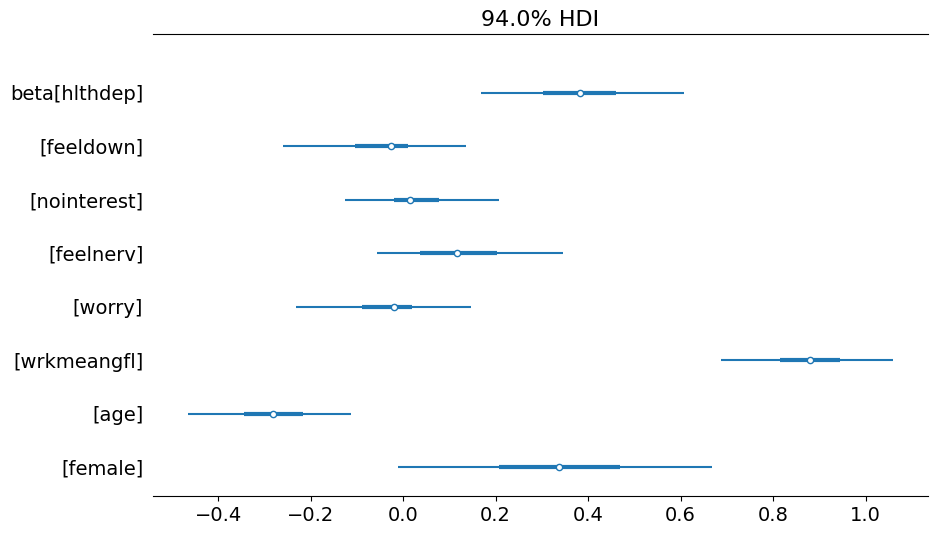

In [14]:
# Forest plot of coefficients
az.plot_forest(trace, var_names=['beta'], combined=True, figsize=(10, 6))

## Results and Interpretation

The horseshoe prior shrinks small effects toward zero while preserving larger effects. Let's examine which predictors are most important.

In [15]:
# Detailed coefficient analysis
beta_samples = trace.posterior['beta'].values
beta_samples_flat = beta_samples.reshape(-1, D)

print('=== COEFFICIENT SUMMARY ===')
print('\nPositive coefficients indicate higher values predict LOWER job satisfaction (higher satjob code)')
print('Negative coefficients indicate higher values predict HIGHER job satisfaction\n')

results = []
for i, name in enumerate(predictor_names):
    samples = beta_samples_flat[:, i]
    mean = samples.mean()
    std = samples.std()
    hdi_low, hdi_high = np.percentile(samples, [3, 97])
    prob_positive = (samples > 0).mean()
    prob_meaningful = (np.abs(samples) > 0.1).mean()  # |beta| > 0.1
    
    results.append({
        'Predictor': name,
        'Mean': mean,
        'SD': std,
        'HDI 3%': hdi_low,
        'HDI 97%': hdi_high,
        'P(β > 0)': prob_positive,
        'P(|β| > 0.1)': prob_meaningful
    })

results_df = pd.DataFrame(results).sort_values('P(|β| > 0.1)', ascending=False)
print(results_df.to_string(index=False, float_format='{:.3f}'.format))

=== COEFFICIENT SUMMARY ===

Positive coefficients indicate higher values predict LOWER job satisfaction (higher satjob code)
Negative coefficients indicate higher values predict HIGHER job satisfaction

 Predictor   Mean    SD  HDI 3%  HDI 97%  P(β > 0)  P(|β| > 0.1)
wrkmeangfl  0.880 0.099   0.693    1.066     1.000         1.000
   hlthdep  0.380 0.119   0.157    0.597     0.999         0.990
       age -0.280 0.094  -0.457   -0.101     0.001         0.971
    female  0.337 0.188   0.001    0.692     0.971         0.882
  feelnerv  0.127 0.114  -0.044    0.361     0.877         0.557
  feeldown -0.046 0.101  -0.268    0.126     0.333         0.313
     worry -0.036 0.097  -0.250    0.133     0.374         0.278
nointerest  0.030 0.086  -0.119    0.218     0.620         0.237


In [16]:
# Analyze shrinkage behavior
tau_samples = trace.posterior['tau'].values.flatten()
lam_samples = trace.posterior['lam'].values.reshape(-1, D)

# Compute shrinkage factors: kappa_j = 1 / (1 + tau^2 * lambda_j^2)
# Values near 1 indicate strong shrinkage, near 0 indicate weak shrinkage
kappa = 1 / (1 + (tau_samples[:, None] ** 2) * (lam_samples ** 2))

print('=== SHRINKAGE ANALYSIS ===')
print('\nShrinkage factor κ: values near 1 = strong shrinkage (toward 0)')
print('                    values near 0 = weak shrinkage (signal preserved)\n')

shrinkage_df = pd.DataFrame({
    'Predictor': predictor_names,
    'Mean κ': kappa.mean(axis=0),
    'Median κ': np.median(kappa, axis=0),
    'P(κ > 0.5)': (kappa > 0.5).mean(axis=0)
}).sort_values('Mean κ')

print(shrinkage_df.to_string(index=False, float_format='{:.3f}'.format))

print(f'\nGlobal shrinkage (tau): mean = {tau_samples.mean():.4f}, median = {np.median(tau_samples):.4f}')

=== SHRINKAGE ANALYSIS ===

Shrinkage factor κ: values near 1 = strong shrinkage (toward 0)
                    values near 0 = weak shrinkage (signal preserved)

 Predictor  Mean κ  Median κ  P(κ > 0.5)
wrkmeangfl   0.676     0.722       0.830
   hlthdep   0.819     0.881       0.931
    female   0.833     0.895       0.933
       age   0.848     0.908       0.948
  feelnerv   0.904     0.963       0.967
  feeldown   0.926     0.981       0.970
     worry   0.928     0.981       0.975
nointerest   0.933     0.982       0.978

Global shrinkage (tau): mean = 0.3690, median = 0.3092


In [17]:
# Visualize coefficient posteriors
fig = make_subplots(rows=2, cols=4, subplot_titles=predictor_names)

for i, name in enumerate(predictor_names):
    row = i // 4 + 1
    col = i % 4 + 1
    samples = beta_samples_flat[:, i]
    
    fig.add_trace(
        go.Histogram(x=samples, name=name, showlegend=False, 
                    marker_color='steelblue', opacity=0.7),
        row=row, col=col
    )
    
    # Add vertical line at 0
    fig.add_vline(x=0, line_dash='dash', line_color='red', row=row, col=col)

fig.update_layout(height=500, title='Posterior Distributions of Coefficients')
fig.show()

## Posterior Predictive Check

In [18]:
# Posterior predictive check
observed_counts = pd.Series(y_observed).value_counts().sort_index()

pp_samples = trace.posterior_predictive['y_obs'].values
n_samples = pp_samples.shape[0] * pp_samples.shape[1]

# Calculate predicted frequencies
predicted_counts = []
for chain in range(pp_samples.shape[0]):
    for draw in range(pp_samples.shape[1]):
        sample_counts = pd.Series(pp_samples[chain, draw, :]).value_counts()
        full_counts = pd.Series(0, index=[0, 1, 2, 3])
        full_counts.update(sample_counts)
        predicted_counts.append(full_counts.values)

predicted_counts = np.array(predicted_counts)
pred_mean = predicted_counts.mean(axis=0)
pred_q05 = np.percentile(predicted_counts, 5, axis=0)
pred_q95 = np.percentile(predicted_counts, 95, axis=0)

# Plot
categories = ['Very Satisfied', 'Mod. Satisfied', 'A Little Dissatisfied', 'Very Dissatisfied']

fig = go.Figure()
fig.add_trace(go.Bar(
    x=categories, y=observed_counts.values,
    name='Observed', marker_color='darkblue', opacity=0.8
))
fig.add_trace(go.Bar(
    x=categories, y=pred_mean,
    error_y=dict(type='data', array=pred_q95-pred_mean, arrayminus=pred_mean-pred_q05),
    name='Predicted (90% CI)', marker_color='lightcoral', opacity=0.7
))

fig.update_layout(
    title='Posterior Predictive Check: Horseshoe Model',
    xaxis_title='Job Satisfaction',
    yaxis_title='Count',
    barmode='group'
)
fig.show()

# Check calibration
within_ci = [(pred_q05[i] <= observed_counts.iloc[i] <= pred_q95[i]) for i in range(4)]
print(f'Observed counts within 90% prediction intervals: {sum(within_ci)}/4')

Observed counts within 90% prediction intervals: 4/4


## Model Comparison: Effect of Regularization

Let's compare the horseshoe coefficients with what we would get from a non-regularized model to see the effect of shrinkage.

In [19]:
# Fit a simple model without horseshoe for comparison
with pm.Model(coords={'predictors': predictor_names}) as simple_model:
    X_data = pm.Data('X_data', X)
    
    # Simple normal priors (no shrinkage)
    beta_simple = pm.Normal('beta', mu=0, sigma=1, dims='predictors')
    mu_simple = pm.Normal('mu', mu=0, sigma=2)
    
    cutpoints = pm.Normal('cutpoints', mu=[-1, 0, 1], sigma=2, shape=K-1,
                         transform=pm.distributions.transforms.ordered)
    
    eta = mu_simple + X_data @ beta_simple
    
    y_obs = pm.OrderedLogistic('y_obs', cutpoints=cutpoints, eta=eta, observed=y_observed)
    
    trace_simple = pm.sample(draws=2000, tune=1000, target_accept=0.95, random_seed=42)

print('Simple model fitted for comparison.')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, mu, cutpoints]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 25 seconds.


Simple model fitted for comparison.


In [20]:
# Compare coefficients
beta_horseshoe = trace.posterior['beta'].mean(dim=['chain', 'draw']).values
beta_simple_mean = trace_simple.posterior['beta'].mean(dim=['chain', 'draw']).values

comparison_df = pd.DataFrame({
    'Predictor': predictor_names,
    'Horseshoe': beta_horseshoe,
    'Simple': beta_simple_mean,
    'Shrinkage': 1 - np.abs(beta_horseshoe) / (np.abs(beta_simple_mean) + 1e-6)
})

print('=== COEFFICIENT COMPARISON ===')
print('\nShrinkage column shows how much the horseshoe shrinks relative to simple model')
print('(Positive = shrunk toward 0, Negative = enhanced)\n')
print(comparison_df.to_string(index=False, float_format='{:.3f}'.format))

# Visualization
fig = go.Figure()
fig.add_trace(go.Bar(
    x=predictor_names, y=beta_simple_mean,
    name='Simple Model', marker_color='lightblue'
))
fig.add_trace(go.Bar(
    x=predictor_names, y=beta_horseshoe,
    name='Horseshoe Model', marker_color='darkblue'
))

fig.update_layout(
    title='Coefficient Comparison: Simple vs Horseshoe',
    xaxis_title='Predictor',
    yaxis_title='Coefficient (Mean)',
    barmode='group'
)
fig.show()

=== COEFFICIENT COMPARISON ===

Shrinkage column shows how much the horseshoe shrinks relative to simple model
(Positive = shrunk toward 0, Negative = enhanced)

 Predictor  Horseshoe  Simple  Shrinkage
   hlthdep      0.380   0.442      0.138
  feeldown     -0.046  -0.140      0.669
nointerest      0.030   0.067      0.551
  feelnerv      0.127   0.212      0.401
     worry     -0.036  -0.118      0.694
wrkmeangfl      0.880   0.910      0.033
       age     -0.280  -0.317      0.114
    female      0.337   0.462      0.270


## Conclusions

### Key Findings

The horseshoe prior provides adaptive regularization that:

1. **Identifies important predictors**: Variables with strong evidence of association with job satisfaction are preserved with minimal shrinkage.

2. **Handles multicollinearity**: The mental health variables (hlthdep, feeldown, nointerest, feelnerv, worry) are correlated. The horseshoe prior helps identify which carry unique predictive information vs. which are redundant.

3. **Provides uncertainty quantification**: Full posterior distributions allow us to assess both effect sizes and confidence in those effects.

### Interpreting Coefficients

- **Positive coefficients**: Higher predictor values → higher probability of dissatisfaction
- **Negative coefficients**: Higher predictor values → higher probability of satisfaction
- **Coefficients near zero with high shrinkage**: Predictor provides little unique predictive information

### Limitations

1. **Missing variables**: Several requested predictors (STRESS, FINRELA, DISCAFFMV, WKAGEISM, WKRACISM, WKSEXISM) were not available in the dataset.

2. **Sample size**: With 554 complete cases, we have limited power to detect small effects.

3. **Cross-sectional data**: Cannot infer causality from these associations.

### Technical Notes

- The regularized horseshoe uses a slab component to bound coefficients
- Non-centered parameterization improves MCMC sampling efficiency
- High target_accept (0.99) needed due to heavy-tailed horseshoe distributions